In [1]:
# ── Imports ───────────────────────────────────────────────────────────────────
import json
import math
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, f1_score, roc_auc_score,
    precision_score, recall_score, confusion_matrix,
    roc_curve, precision_recall_curve, average_precision_score,
    ConfusionMatrixDisplay
)

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)


warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
print('Imports OK')

/home/tan/anaconda3/envs/kangal/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda
Imports OK


JSONL total: 9624  |  Malware: 8420  Benign: 1204

Seq length stats:
  min=10  max=368  median=31  mean=46.1  p95=128  p99=223
  >128: 478 (5.0%)  >256: 44 (0.5%)


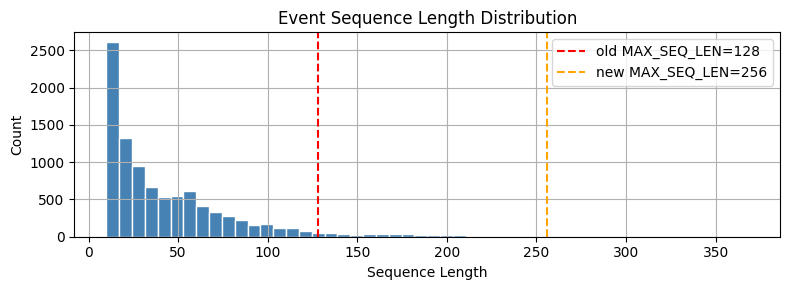

In [2]:
# ── Data Loading — CSV + JSONL ─────────────────────────────────────────────────



# 2. Seq-log JSONL (Transformer için)
def load_jsonl(path):
    records = []
    with open(path, encoding='utf-8') as f:
        for line in f:
            records.append(json.loads(line))
    return records

seq_mal = load_jsonl('kangal_malware_seqlogs.jsonl')
seq_ben = load_jsonl('krono_benign_seqlogs.jsonl')
seq_all = seq_mal + seq_ben
print(f'JSONL total: {len(seq_all)}  |  Malware: {len(seq_mal)}  Benign: {len(seq_ben)}')

# 3. Seq-log → DataFrame (Transformer verisi)
df_seq = pd.DataFrame([
    {
        'package_name'       : r['package_name'],
        'label'              : r['label'],
        'session_duration_ms': r['session_duration_ms'],
        'seq_log'            : r['seq_log'],
    }
    for r in seq_all
])
df_seq['label_bin'] = (df_seq['label'] == 'malware').astype(int)

seq_lens = df_seq['seq_log'].apply(len)
print(f'\nSeq length stats:')
print(f'  min={seq_lens.min()}  max={seq_lens.max()}  '
      f'median={seq_lens.median():.0f}  mean={seq_lens.mean():.1f}  '
      f'p95={seq_lens.quantile(0.95):.0f}  p99={seq_lens.quantile(0.99):.0f}')
print(f'  >128: {(seq_lens > 128).sum()} ({100*(seq_lens>128).mean():.1f}%)'
      f'  >256: {(seq_lens > 256).sum()} ({100*(seq_lens>256).mean():.1f}%)')

# Histogram
plt.figure(figsize=(8, 3))
seq_lens.hist(bins=50, color='steelblue', edgecolor='white')
plt.axvline(128, color='red',    linestyle='--', label='old MAX_SEQ_LEN=128')
plt.axvline(256, color='orange', linestyle='--', label='new MAX_SEQ_LEN=256')
plt.xlabel('Sequence Length')
plt.ylabel('Count')
plt.title('Event Sequence Length Distribution')
plt.legend()
plt.tight_layout()
plt.show()


In [3]:
# ── Vocabulary & Tokenization ─────────────────────────────────────────────────
# 87 tag — KANGAL_FEATURE_REFERENCE.md v4 Bölüm 2
TAGS = [
    # ── MALWARE-EXCLUSIVE (22) ──────────────────────────────────────────────
    'SCREEN_CAPTURE',      'INPUT_INJECT',        'KEYLOG',
    'PKG_INSTALL',         'PKG_DISABLE',
    'NOTIF_LISTEN',        'PHONE_CALL_SILENT',   'PHONE_STATE_LISTEN',
    'PERM_ADMIN_REQ',      'ACCOUNT_TOKEN_STEAL', 'KEYSTORE_EXFIL',
    'WEBVIEW_JS_BRIDGE',   'WEBVIEW_JS_EXEC',
    'MEM_EXEC_MMAP',       'DEX_LOAD_MEMORY',
    'FILE_ENCRYPT_BULK',
    'ANTI_HOOK_DETECT',    'ANTI_VM_PROPS',
    'BCAST_SMS_INTERCEPT', 'BCAST_SCREEN_WAKE',
    'ROOT_HIDE',           'ROOT_PERSIST_SYSTEM',
    # ── BENIGN-EXCLUSIVE (11) ───────────────────────────────────────────────
    'ADS_SDK_INIT',        'ANALYTICS_LOG',       'CRASH_REPORT',
    'IN_APP_PURCHASE',     'AUTH_OAUTH',           'AUTH_BIOMETRIC',
    'MAPS_API',            'CLOUD_STORAGE',        'SOCIAL_SHARE',
    'MEDIA_PLAY',          'NOTIF_POST_LEGIT',
    # ── NETWORK (7) ─────────────────────────────────────────────────────────
    'NET_HTTP_GET',        'NET_HTTP_POST',
    'NET_SOCKET_TCP',      'NET_SOCKET_UDP',
    'NET_DNS_LOOKUP',      'NET_SSL_BYPASS',       'NET_WEBSOCKET',
    # ── CRYPTO (7) ──────────────────────────────────────────────────────────
    'CRYPTO_AES',          'CRYPTO_RSA',
    'CRYPTO_HASH_MD5',     'CRYPTO_HASH_SHA',
    'CRYPTO_BASE64_ENC',   'CRYPTO_BASE64_DEC',    'CRYPTO_KEYGEN',
    # ── REFLECTION & LOADING (5) ────────────────────────────────────────────
    'REFLECT_INVOKE',      'REFLECT_CLASS_LOAD',   'REFLECT_FIELD_ACCESS',
    'DEX_LOAD_FILE',       'NATIVE_LIB_LOAD',
    # ── SURVEILLANCE (8) ────────────────────────────────────────────────────
    'SURV_DEVICE_ID',
    'SURV_LOCATION_GPS',   'SURV_LOCATION_NET',
    'SURV_CONTACT_READ',   'SURV_SMS_READ',        'SURV_CALL_LOG',
    'SURV_CAMERA',         'SURV_MIC_RECORD',
    # ── FILE OPERATIONS (4) ─────────────────────────────────────────────────
    'FILE_WRITE_INTERNAL', 'FILE_WRITE_EXTERNAL',
    'FILE_READ_SENSITIVE', 'FILE_DELETE',
    # ── EXECUTION (2) ───────────────────────────────────────────────────────
    'EXEC_SHELL_CMD',      'EXEC_ROOT_CMD',
    # ── PERSISTENCE (4) ─────────────────────────────────────────────────────
    'PERSIST_BOOT_RECV',   'PERSIST_ALARM_REP',
    'PERSIST_JOB_SCHED',   'PERSIST_FG_SERVICE',
    # ── ANTI-ANALYSIS (4) ───────────────────────────────────────────────────
    'ANTI_DEBUG',          'ANTI_EMULATOR',
    'ANTI_ROOT_CHECK',     'ANTI_SLEEP_LONG',
    # ── PACKAGE (1) ─────────────────────────────────────────────────────────
    'PKG_ENUMERATE',
    # ── IPC (3) ─────────────────────────────────────────────────────────────
    'IPC_BIND_SERVICE',    'IPC_SEND_BROADCAST',  'IPC_IMPLICIT_INTENT',
    # ── ACCESSIBILITY (3) ───────────────────────────────────────────────────
    'ACC_SERVICE_BIND',    'ACC_ACTION',           'ACC_WINDOW_ACCESS',
    # ── MEDIA & CONTENT (2) ─────────────────────────────────────────────────
    'MEDIA_PHOTO_ACCESS',  'MEDIA_VIDEO_ACCESS',
    # ── UI ABUSE (2) ────────────────────────────────────────────────────────
    'OVERLAY_WINDOW',      'CLIPBOARD_ACCESS',
    # ── C2 CHANNEL (2) ──────────────────────────────────────────────────────
    'PUSH_CHANNEL_REG',    'REMOTE_CONFIG_FETCH',
]
# Toplam: 87 tag

PAD_ID     = 0
TAG2ID     = {tag: i+1 for i, tag in enumerate(TAGS)}
ID2TAG     = {v: k for k, v in TAG2ID.items()}
VOCAB_SIZE = len(TAGS) + 1   # 88

# ── Aktif tag analizi ─────────────────────────────────────────────────────────
_data_tags: set = set()
for _r in seq_all:
    for _e in _r['seq_log']:
        _data_tags.add(_e['tag'])

ACTIVE_TAG_MASK = np.array(
    [1.0 if tag in _data_tags else 0.0 for tag in TAGS],
    dtype=np.float32
)
N_ACTIVE_TAGS = int(ACTIVE_TAG_MASK.sum())
print(f'Vocabulary size : {VOCAB_SIZE}  (87 tag + PAD)')
print(f'Tags in data    : {N_ACTIVE_TAGS} / {len(TAGS)}  '
      f'({len(TAGS) - N_ACTIVE_TAGS} tag hiç ateşlenmiyor)')

# Maksimum burst değeri
_MAX_BURST = max(
    (e['burst'] for r in seq_all for e in r['seq_log'] if 'burst' in e),
    default=30
)
_LOG_MAX_BURST = math.log1p(_MAX_BURST)
print(f'Max burst in data: {_MAX_BURST}  (log1p scale: {_LOG_MAX_BURST:.3f})')

# Malware / benign exclusive grupları
MAL_EXCLUSIVE = [
    'SCREEN_CAPTURE','INPUT_INJECT','KEYLOG','PKG_INSTALL','PKG_DISABLE',
    'NOTIF_LISTEN','PHONE_CALL_SILENT','PHONE_STATE_LISTEN','PERM_ADMIN_REQ',
    'ACCOUNT_TOKEN_STEAL','KEYSTORE_EXFIL','WEBVIEW_JS_BRIDGE','WEBVIEW_JS_EXEC',
    'MEM_EXEC_MMAP','DEX_LOAD_MEMORY','FILE_ENCRYPT_BULK',
    'ANTI_HOOK_DETECT','ANTI_VM_PROPS','BCAST_SMS_INTERCEPT','BCAST_SCREEN_WAKE',
    'ROOT_HIDE','ROOT_PERSIST_SYSTEM',
]
BEN_EXCLUSIVE = [
    'ADS_SDK_INIT','ANALYTICS_LOG','CRASH_REPORT','IN_APP_PURCHASE',
    'AUTH_OAUTH','AUTH_BIOMETRIC','MAPS_API','CLOUD_STORAGE',
    'SOCIAL_SHARE','MEDIA_PLAY','NOTIF_POST_LEGIT',
]

# ── N-gram Vocabulary ─────────────────────────────────────────────────────────
# Bigram/trigram frekansları TÜM sequence'lardan (train+val+test) hesaplanır.
# Label bilgisi kullanılmaz → label leakage yok.
# Amaç: Transformer'ın örtük olarak öğrendiği geçiş örüntülerini
#       açık sayısal özellik olarak modele sunmak.
from collections import Counter as _Counter

N_BIGRAMS  = 150
N_TRIGRAMS = 100
N_NGRAMS   = N_BIGRAMS + N_TRIGRAMS   # 250

_bigram_cnt  = _Counter()
_trigram_cnt = _Counter()
for _r in seq_all:
    _tags = [_e['tag'] for _e in _r['seq_log']]
    for _i in range(len(_tags) - 1):
        _bigram_cnt[(_tags[_i], _tags[_i+1])] += 1
    for _i in range(len(_tags) - 2):
        _trigram_cnt[(_tags[_i], _tags[_i+1], _tags[_i+2])] += 1

TOP_BIGRAMS  = [bg for bg, _ in _bigram_cnt.most_common(N_BIGRAMS)]
TOP_TRIGRAMS = [tg for tg, _ in _trigram_cnt.most_common(N_TRIGRAMS)]
BIGRAM2ID    = {bg: i           for i, bg in enumerate(TOP_BIGRAMS)}
TRIGRAM2ID   = {tg: i+N_BIGRAMS for i, tg in enumerate(TOP_TRIGRAMS)}

print(f'\nN-gram vocabulary: {N_BIGRAMS} bigrams + {N_TRIGRAMS} trigrams = {N_NGRAMS} features')
print(f'  En sık bigram-5  : {TOP_BIGRAMS[:5]}')
print(f'  En sık trigram-5 : {TOP_TRIGRAMS[:5]}')

def encode_seq(seq_log, session_duration_ms, max_len=256):
    """
    Returns:
        tag_ids    : np.int64   [max_len]   — 0=PAD
        time_vals  : np.float32 [max_len]   — ms/dur  (0–1)
        delta_vals : np.float32 [max_len]   — delta_ms/dur (0–1)
        burst_vals : np.float32 [max_len]   — log1p(burst)/log1p(max_burst) (0–1)
        attn_mask  : np.bool_   [max_len]   — True=PAD
        tag_freq   : np.float32 [len(TAGS)] — burst-weighted relative tag frequency
        ngram_feat : np.float32 [N_NGRAMS]  — normalized bigram+trigram counts
    """
    dur    = max(session_duration_ms, 1)
    events = seq_log[:max_len]

    tag_ids    = np.zeros(max_len,   dtype=np.int64)
    time_vals  = np.zeros(max_len,   dtype=np.float32)
    delta_vals = np.zeros(max_len,   dtype=np.float32)
    burst_vals = np.zeros(max_len,   dtype=np.float32)
    attn_mask  = np.ones(max_len,    dtype=bool)
    tag_freq   = np.zeros(len(TAGS), dtype=np.float32)
    ngram_feat = np.zeros(N_NGRAMS,  dtype=np.float32)

    prev_ms = 0
    raw_tags = []
    for i, ev in enumerate(events):
        tid           = TAG2ID.get(ev['tag'], PAD_ID)
        cur_ms        = ev['ms']
        burst         = ev.get('burst', 1)
        tag_ids[i]    = tid
        time_vals[i]  = min(cur_ms / dur, 1.0)
        delta_vals[i] = min((cur_ms - prev_ms) / dur, 1.0)
        burst_vals[i] = math.log1p(burst) / _LOG_MAX_BURST
        attn_mask[i]  = False
        if tid > 0:
            tag_freq[tid - 1] += burst
        raw_tags.append(ev['tag'])
        prev_ms = cur_ms

    # Bigram sayımı
    for i in range(len(raw_tags) - 1):
        bg = (raw_tags[i], raw_tags[i+1])
        if bg in BIGRAM2ID:
            ngram_feat[BIGRAM2ID[bg]] += 1.0

    # Trigram sayımı
    for i in range(len(raw_tags) - 2):
        tg = (raw_tags[i], raw_tags[i+1], raw_tags[i+2])
        if tg in TRIGRAM2ID:
            ngram_feat[TRIGRAM2ID[tg]] += 1.0

    # Normalize
    total = tag_freq.sum()
    if total > 0:
        tag_freq /= total

    ng_total = ngram_feat.sum()
    if ng_total > 0:
        ngram_feat /= ng_total

    return tag_ids, time_vals, delta_vals, burst_vals, attn_mask, tag_freq, ngram_feat

print('encode_seq OK (tag_ids, time_vals, delta_vals, burst_vals, attn_mask, tag_freq, ngram_feat)')

Vocabulary size : 88  (87 tag + PAD)
Tags in data    : 60 / 87  (27 tag hiç ateşlenmiyor)
Max burst in data: 29  (log1p scale: 3.401)

N-gram vocabulary: 150 bigrams + 100 trigrams = 250 features
  En sık bigram-5  : [('REFLECT_CLASS_LOAD', 'REFLECT_CLASS_LOAD'), ('FILE_WRITE_INTERNAL', 'FILE_WRITE_INTERNAL'), ('FILE_WRITE_INTERNAL', 'FILE_DELETE'), ('REFLECT_FIELD_ACCESS', 'REFLECT_FIELD_ACCESS'), ('NET_HTTP_GET', 'NET_DNS_LOOKUP')]
  En sık trigram-5 : [('REFLECT_CLASS_LOAD', 'REFLECT_CLASS_LOAD', 'REFLECT_CLASS_LOAD'), ('FILE_WRITE_INTERNAL', 'FILE_WRITE_INTERNAL', 'FILE_DELETE'), ('FILE_WRITE_INTERNAL', 'FILE_WRITE_INTERNAL', 'FILE_WRITE_INTERNAL'), ('FILE_WRITE_INTERNAL', 'FILE_DELETE', 'FILE_WRITE_INTERNAL'), ('REFLECT_FIELD_ACCESS', 'REFLECT_FIELD_ACCESS', 'REFLECT_CLASS_LOAD')]
encode_seq OK (tag_ids, time_vals, delta_vals, burst_vals, attn_mask, tag_freq, ngram_feat)


In [4]:
# ── PyTorch Dataset & DataLoader ──────────────────────────────────────────────
MAX_SEQ_LEN = 256

class SeqLogDataset(Dataset):
    def __init__(self, df, max_len=MAX_SEQ_LEN):
        self.df      = df.reset_index(drop=True)
        self.max_len = max_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        tag_ids, time_vals, delta_vals, burst_vals, attn_mask, tag_freq, ngram_feat = encode_seq(
            row['seq_log'], row['session_duration_ms'], self.max_len
        )
        return (
            torch.tensor(tag_ids,    dtype=torch.long),
            torch.tensor(time_vals,  dtype=torch.float),
            torch.tensor(delta_vals, dtype=torch.float),
            torch.tensor(burst_vals, dtype=torch.float),
            torch.tensor(attn_mask,  dtype=torch.bool),
            torch.tensor(tag_freq,   dtype=torch.float),
            torch.tensor(ngram_feat, dtype=torch.float),
            torch.tensor(row['label_bin'], dtype=torch.float),
        )

# ── Train / Val / Test split (stratified) ────────────────────────────────────
y_all = df_seq['label_bin'].values

idx_trainval, idx_test = train_test_split(
    np.arange(len(df_seq)), test_size=0.15, stratify=y_all, random_state=42
)
idx_train, idx_val = train_test_split(
    idx_trainval, test_size=0.12, stratify=y_all[idx_trainval], random_state=42
)

print(f'Train: {len(idx_train)}  Val: {len(idx_val)}  Test: {len(idx_test)}')
print(f'Train malware ratio: {y_all[idx_train].mean():.3f}')
print(f'Val   malware ratio: {y_all[idx_val].mean():.3f}')
print(f'Test  malware ratio: {y_all[idx_test].mean():.3f}')

BATCH_SIZE = 64

def dynamic_collate(batch):
    """Batch içindeki en uzun sequence'a göre pad et (global max değil).
    Batch items: tag_ids, time_v, delta_v, burst_v, attn_m, tag_f, ngram_f, labels
    """
    tag_ids, time_v, delta_v, burst_v, attn_m, tag_f, ngram_f, labels = zip(*batch)

    real_lens = [(~m).sum().item() for m in attn_m]
    max_len   = max(real_lens)

    def pad_seq(t, pad_val=0):
        return t[:max_len]

    tag_ids_p  = torch.stack([pad_seq(t) for t in tag_ids])
    time_v_p   = torch.stack([pad_seq(t) for t in time_v])
    delta_v_p  = torch.stack([pad_seq(t) for t in delta_v])
    burst_v_p  = torch.stack([pad_seq(t) for t in burst_v])
    attn_m_p   = torch.stack([pad_seq(t, pad_val=True) for t in attn_m])
    tag_f_p    = torch.stack(list(tag_f))
    ngram_f_p  = torch.stack(list(ngram_f))
    labels_p   = torch.stack(list(labels))
    return tag_ids_p, time_v_p, delta_v_p, burst_v_p, attn_m_p, tag_f_p, ngram_f_p, labels_p

train_ds = SeqLogDataset(df_seq.iloc[idx_train])
val_ds   = SeqLogDataset(df_seq.iloc[idx_val])
test_ds  = SeqLogDataset(df_seq.iloc[idx_test])

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                      num_workers=2, pin_memory=True, collate_fn=dynamic_collate)
val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                      num_workers=2, pin_memory=True, collate_fn=dynamic_collate)
test_dl  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                      num_workers=2, pin_memory=True, collate_fn=dynamic_collate)
print('DataLoaders ready.  (dinamik padding aktif, ngram_feat eklendi)')
print(f'Batch items: tag_ids, time_v, delta_v, burst_v, attn_m, tag_freq, ngram_feat, labels  (8 item)')

Train: 7198  Val: 982  Test: 1444
Train malware ratio: 0.875
Val   malware ratio: 0.875
Test  malware ratio: 0.875
DataLoaders ready.  (dinamik padding aktif, ngram_feat eklendi)
Batch items: tag_ids, time_v, delta_v, burst_v, attn_m, tag_freq, ngram_feat, labels  (8 item)


In [5]:
# ── Self-Supervised Pretraining — Dataset & Model ─────────────────────────────
#
# v3 → v5 strateji değişikliği:
#   v4: Masked Diffusion ile sentetik veri üretimi  → iyileşme görülmedi
#   v5: Self-supervised pretraining → supervised fine-tuning
#       Üç görev: MEM + NEP + TBP
#
# v9: encode_seq artık 7 değer döndürüyor (ngram_feat eklendi).
#     PretrainDataset sadece sequence özelliklerini kullanır → ngram_feat yok sayılır.

MASK_ID        = VOCAB_SIZE          # 88
PRETRAIN_VOCAB = VOCAB_SIZE + 1      # 89
N_TIME_BUCKETS = 10
MASK_PROB      = 0.15
MASK_REPLACE   = 0.80
MASK_RANDOM    = 0.10


class PretrainDataset(Dataset):
    def __init__(self, df, max_len=MAX_SEQ_LEN, mask_prob=MASK_PROB):
        self.df        = df.reset_index(drop=True)
        self.max_len   = max_len
        self.mask_prob = mask_prob

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        # encode_seq 7 değer döndürür; ngram_feat pretrain için kullanılmaz
        tag_ids, time_vals, delta_vals, burst_vals, attn_mask, _, _ = encode_seq(
            row['seq_log'], row['session_duration_ms'], self.max_len
        )

        # Zaman kovası: time_vals [0,1] → ondalık (0-9), PAD → -1
        time_buckets = np.full(self.max_len, -1, dtype=np.int64)
        non_pad = ~attn_mask
        if non_pad.any():
            buckets = np.floor(time_vals[non_pad] * N_TIME_BUCKETS).astype(int)
            time_buckets[non_pad] = np.clip(buckets, 0, N_TIME_BUCKETS - 1)

        # BERT-tarzı maskeleme (MEM için)
        tag_ids_orig   = tag_ids.copy()
        tag_ids_masked = tag_ids.copy()
        mem_mask       = np.zeros(self.max_len, dtype=bool)

        non_pad_idx = np.where(non_pad)[0]
        n_mask      = max(1, int(len(non_pad_idx) * self.mask_prob))
        selected    = np.random.choice(non_pad_idx, size=n_mask, replace=False)
        mem_mask[selected] = True

        for pos in selected:
            r = np.random.random()
            if r < MASK_REPLACE:
                tag_ids_masked[pos] = MASK_ID
            elif r < MASK_REPLACE + MASK_RANDOM:
                tag_ids_masked[pos] = np.random.randint(1, VOCAB_SIZE)

        return (
            torch.tensor(tag_ids_masked, dtype=torch.long),
            torch.tensor(tag_ids_orig,   dtype=torch.long),
            torch.tensor(mem_mask,       dtype=torch.bool),
            torch.tensor(time_vals,      dtype=torch.float),
            torch.tensor(delta_vals,     dtype=torch.float),
            torch.tensor(burst_vals,     dtype=torch.float),
            torch.tensor(attn_mask,      dtype=torch.bool),
            torch.tensor(time_buckets,   dtype=torch.long),
        )


class EventSequencePretrainer(nn.Module):
    """
    Self-supervised ön-eğitim modeli — üç görev: MEM + NEP + TBP.
    embed_dim=256, nhead=8, num_layers=3, ff_dim=512.
    """
    def __init__(
        self,
        vocab_size  = PRETRAIN_VOCAB,
        embed_dim   = 256,
        nhead       = 8,
        num_layers  = 3,
        ff_dim      = 512,
        dropout     = 0.10,
    ):
        super().__init__()
        self.embed_dim = embed_dim

        self.tag_emb = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_ID)
        self.time_proj = nn.Sequential(
            nn.Linear(1, embed_dim // 2), nn.GELU(),
            nn.Linear(embed_dim // 2, embed_dim),
        )
        self.delta_proj = nn.Sequential(
            nn.Linear(1, embed_dim // 2), nn.GELU(),
            nn.Linear(embed_dim // 2, embed_dim),
        )
        self.burst_proj = nn.Sequential(
            nn.Linear(1, embed_dim // 2), nn.GELU(),
            nn.Linear(embed_dim // 2, embed_dim),
        )
        self.input_norm = nn.LayerNorm(embed_dim)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=nhead,
            dim_feedforward=ff_dim,
            dropout=dropout, batch_first=True,
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)

        self.mem_head = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, embed_dim),
            nn.GELU(),
            nn.Linear(embed_dim, VOCAB_SIZE),
        )
        self.nep_head = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, embed_dim),
            nn.GELU(),
            nn.Linear(embed_dim, VOCAB_SIZE),
        )
        self.tbp_head = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, embed_dim // 2),
            nn.GELU(),
            nn.Linear(embed_dim // 2, N_TIME_BUCKETS),
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None: nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Embedding):
                nn.init.normal_(m.weight, std=0.02)
                if m.padding_idx is not None:
                    m.weight.data[m.padding_idx].zero_()

    def forward(self, tag_ids_masked, time_vals, delta_vals, burst_vals, attn_mask):
        tag_e   = self.tag_emb(tag_ids_masked)
        time_e  = self.time_proj(time_vals.unsqueeze(-1))
        delta_e = self.delta_proj(delta_vals.unsqueeze(-1))
        burst_e = self.burst_proj(burst_vals.unsqueeze(-1))
        x       = self.input_norm(tag_e + time_e + delta_e + burst_e)
        out     = self.encoder(x, src_key_padding_mask=attn_mask)
        return self.mem_head(out), self.nep_head(out), self.tbp_head(out)


pretrainer = EventSequencePretrainer().to(DEVICE)
n_params   = sum(p.numel() for p in pretrainer.parameters() if p.requires_grad)
print(f'EventSequencePretrainer — trainable params: {n_params:,}')
print(f'  embed_dim=256  nhead=8  num_layers=3  ff_dim=512  dropout=0.10')
print(f'  Görevler: MEM + NEP + TBP')
print(f'  MASK_ID={MASK_ID}  PRETRAIN_VOCAB={PRETRAIN_VOCAB}  N_TIME_BUCKETS={N_TIME_BUCKETS}')
print(f'  PretrainDataset: encode_seq 7 değer (ngram_feat yok sayılır)')

EventSequencePretrainer — trainable params: 1,916,986
  embed_dim=256  nhead=8  num_layers=3  ff_dim=512  dropout=0.10
  Görevler: MEM + NEP + TBP
  MASK_ID=88  PRETRAIN_VOCAB=89  N_TIME_BUCKETS=10
  PretrainDataset: encode_seq 7 değer (ngram_feat yok sayılır)


Pretraining: 8180 sequence  (7198 train + 982 val,  test dokunulmadı)
PRETRAIN_EPOCHS=150  (v8 ile aynı)



 Epoch        LR     Total      MEM      NEP      TBP
----------------------------------------------------------
     1  3.00e-04    5.2317   2.6327   2.3074   0.5833
    10  2.97e-04    3.6718   2.0338   1.5750   0.1260
    20  2.87e-04    3.4493   1.9304   1.4710   0.0958
    30  2.72e-04    3.2995   1.8487   1.4083   0.0851
    40  2.52e-04    3.2001   1.7994   1.3625   0.0764
    50  2.28e-04    3.1193   1.7563   1.3257   0.0747
    60  2.00e-04    3.0348   1.7082   1.2938   0.0654
    70  1.70e-04    2.9698   1.6744   1.2657   0.0594
    80  1.40e-04    2.9149   1.6449   1.2396   0.0607
    90  1.10e-04    2.8538   1.6090   1.2176   0.0544
   100  8.25e-05    2.8060   1.5805   1.2007   0.0496
   110  5.80e-05    2.7833   1.5723   1.1866   0.0488
   120  3.77e-05    2.7561   1.5583   1.1743   0.0470
   130  2.25e-05    2.7241   1.5353   1.1661   0.0455
   140  1.32e-05    2.7063   1.5219   1.1619   0.0450
   150  1.00e-05    2.7044   1.5226   1.1591   0.0454

Ön-eğitim tamamlandı.

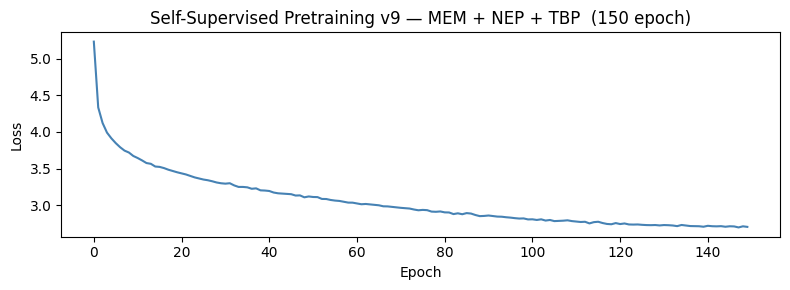

Pretrained encoder ağırlıkları MalwareTransformerV9 için hazır.


In [6]:
# ── Self-Supervised Pretraining — Eğitim Döngüsü ──────────────────────────────
#
# Sadece train+val sequence'ları kullanılır (LABEL YOK, test seti dokunulmaz).
# L_total = L_mem + L_nep + λ_tbp × L_tbp
#
# v8: PRETRAIN_EPOCHS=150 (v7:100, loss hâlâ düşüyordu)
# v9: v8 ile aynı pretrain — yeni ngram branch fine-tuning'de ekleniyor.

PRETRAIN_EPOCHS  = 150
PRETRAIN_LR      = 3e-4
PRETRAIN_BATCH   = 64
TBP_WEIGHT       = 0.5

df_pretrain  = df_seq.iloc[np.concatenate([idx_train, idx_val])].reset_index(drop=True)
pretrain_ds  = PretrainDataset(df_pretrain)

def pretrain_collate(batch):
    tag_m, tag_o, mem_mask, time_v, delta_v, burst_v, attn_m, tbuckets = zip(*batch)
    real_lens = [(~m).sum().item() for m in attn_m]
    max_len   = max(real_lens)
    def pad(t, pv=0): return t[:max_len]
    def pad_bool(t, pv=True): return t[:max_len]
    return (
        torch.stack([pad(t)      for t in tag_m]),
        torch.stack([pad(t)      for t in tag_o]),
        torch.stack([pad_bool(t, False) for t in mem_mask]),
        torch.stack([pad(t)      for t in time_v]),
        torch.stack([pad(t)      for t in delta_v]),
        torch.stack([pad(t)      for t in burst_v]),
        torch.stack([pad_bool(t) for t in attn_m]),
        torch.stack([pad(t, -1)  for t in tbuckets]),
    )

pretrain_dl  = DataLoader(pretrain_ds, batch_size=PRETRAIN_BATCH, shuffle=True,
                          num_workers=2, pin_memory=True, collate_fn=pretrain_collate)
print(f'Pretraining: {len(pretrain_ds)} sequence  '
      f'({len(idx_train)} train + {len(idx_val)} val,  test dokunulmadı)')
print(f'PRETRAIN_EPOCHS={PRETRAIN_EPOCHS}  (v8 ile aynı)')

pretrain_opt   = AdamW(pretrainer.parameters(), lr=PRETRAIN_LR, weight_decay=1e-2)
pretrain_sched = CosineAnnealingLR(pretrain_opt, T_max=PRETRAIN_EPOCHS, eta_min=1e-5)

mem_crit = nn.CrossEntropyLoss(ignore_index=PAD_ID)
nep_crit = nn.CrossEntropyLoss(ignore_index=PAD_ID)
tbp_crit = nn.CrossEntropyLoss(ignore_index=-1)

pretrain_history = []

print(f"\n{'Epoch':>6}  {'LR':>8}  {'Total':>8}  {'MEM':>7}  {'NEP':>7}  {'TBP':>7}")
print('-' * 58)

for epoch in range(1, PRETRAIN_EPOCHS + 1):
    pretrainer.train()
    tot, mem_t, nep_t, tbp_t, nb = 0.0, 0.0, 0.0, 0.0, 0

    for batch in pretrain_dl:
        (tag_masked, tag_orig, mem_mask,
         time_v, delta_v, burst_v,
         attn_mask, time_buckets) = [b.to(DEVICE) for b in batch]

        mem_logits, nep_logits, tbp_logits = pretrainer(
            tag_masked, time_v, delta_v, burst_v, attn_mask
        )
        B, L, V = mem_logits.shape

        mem_targets = tag_orig.view(B * L).clone()
        mem_targets[~mem_mask.view(B * L)] = PAD_ID
        l_mem = mem_crit(mem_logits.view(B * L, V), mem_targets)

        nep_pred    = nep_logits[:, :-1, :].reshape(-1, V)
        nep_targets = tag_orig[:, 1:].reshape(-1)
        l_nep = nep_crit(nep_pred, nep_targets)

        l_tbp = tbp_crit(tbp_logits.view(B * L, N_TIME_BUCKETS),
                         time_buckets.view(B * L))

        loss = l_mem + l_nep + TBP_WEIGHT * l_tbp
        pretrain_opt.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(pretrainer.parameters(), 1.0)
        pretrain_opt.step()

        tot   += loss.item()
        mem_t += l_mem.item()
        nep_t += l_nep.item()
        tbp_t += l_tbp.item()
        nb    += 1

    pretrain_sched.step()
    pretrain_history.append(tot / nb)

    if epoch % 10 == 0 or epoch == 1:
        lr = pretrain_sched.get_last_lr()[0]
        print(f'{epoch:>6}  {lr:>8.2e}  {tot/nb:>8.4f}  '
              f'{mem_t/nb:>7.4f}  {nep_t/nb:>7.4f}  {tbp_t/nb:>7.4f}')

print('\nÖn-eğitim tamamlandı.')

plt.figure(figsize=(8, 3))
plt.plot(pretrain_history, color='steelblue')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title('Self-Supervised Pretraining v9 — MEM + NEP + TBP  (150 epoch)')
plt.tight_layout(); plt.show()

print('Pretrained encoder ağırlıkları MalwareTransformerV9 için hazır.')

In [7]:
# ── MalwareTransformerV9 — v8 + N-gram Branch ────────────────────────────────
#
# v8 → v9 değişikliği (tek değişiklik):
#
#   YENİ: N-gram Branch (ngram_proj)
#     Giriş  : ngram_feat [N_NGRAMS=250]  — normalize bigram+trigram sayımları
#     Çıkış  : 256-dim vektör
#     Mimari : Linear(250→256) → GELU → LayerNorm → Dropout
#              → Linear(256→256) → GELU → LayerNorm
#
#   Motivasyon:
#     Transformer attention, geçiş örüntülerini (örn. REFLECT_INVOKE→DEX_LOAD_MEMORY)
#     örtük olarak kodlar. Ancak bunu global dikkat matrisi üzerinden yapar.
#     N-gram branch, bu bilgiyi açık bir sayısal özellik olarak sunar:
#       - Sınır örnekleri için ek sinyal → val performansı artar
#       - Modelin attention mekanizmasına bağımlılığı azalır
#       - 250-dim küçük vektör → overfitting riski düşük
#
#   Füzyon: [cls | tf_mean | lstm_out | freq_out | ngram_out] = 5×256=1280
#   Diğer tüm parametreler v8 ile aynı:
#     dropout=0.30, lstm_dropout=0.25, noise_sigma=0.10
#     LSTM: last_hidden + mean_pool (residual)

class MalwareTransformerV9(nn.Module):
    """
    Hibrit: SSL-Pretrained Transformer + BiLSTM + Freq + N-gram Branch

    Akış:
      tag_ids, time_vals, delta_vals, burst_vals
          → Ortak Embedding (pretrained) + Diffusion Noise (σ=0.10)
          ├── Transformer Branch → CLS + mean-pool   (2×256)
          └── BiLSTM Branch     → last + mean-pool residual (256)
      tag_freq  → Freq Branch   (256)
      ngram_feat → N-gram Branch (256)
      Füzyon → [cls|tf_mean|lstm_out|freq_out|ngram_out] = 5×256=1280 → 256 → 1
    """
    def __init__(
        self,
        vocab_size    = PRETRAIN_VOCAB,
        embed_dim     = 256,
        nhead         = 8,
        num_layers    = 3,
        ff_dim        = 512,
        dropout       = 0.30,
        token_drop_p  = 0.10,
        lstm_hidden   = 128,
        lstm_layers   = 2,
        lstm_dropout  = 0.25,
        noise_sigma   = 0.10,
        n_tags        = len(TAGS),
        n_ngrams      = N_NGRAMS,
    ):
        super().__init__()
        self.embed_dim    = embed_dim
        self.token_drop_p = token_drop_p
        self.noise_sigma  = noise_sigma

        # ── Ortak Embedding (pretrained) ──────────────────────────────────────
        self.tag_emb = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_ID)
        self.time_proj = nn.Sequential(
            nn.Linear(1, embed_dim // 2), nn.GELU(),
            nn.Linear(embed_dim // 2, embed_dim),
        )
        self.delta_proj = nn.Sequential(
            nn.Linear(1, embed_dim // 2), nn.GELU(),
            nn.Linear(embed_dim // 2, embed_dim),
        )
        self.burst_proj = nn.Sequential(
            nn.Linear(1, embed_dim // 2), nn.GELU(),
            nn.Linear(embed_dim // 2, embed_dim),
        )
        self.input_norm = nn.LayerNorm(embed_dim)

        # ── Transformer Branch (pretrained) ──────────────────────────────────
        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim) * 0.02)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=nhead,
            dim_feedforward=ff_dim,
            dropout=dropout, batch_first=True,
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)

        # ── BiLSTM Branch ────────────────────────────────────────────────────
        self.bilstm = nn.LSTM(
            input_size    = embed_dim,
            hidden_size   = lstm_hidden,
            num_layers    = lstm_layers,
            dropout       = lstm_dropout if lstm_layers > 1 else 0.0,
            bidirectional = True,
            batch_first   = True,
        )
        self.lstm_norm = nn.LayerNorm(lstm_hidden * 2)

        # ── Frequency Branch ─────────────────────────────────────────────────
        self.register_buffer('active_mask', torch.tensor(ACTIVE_TAG_MASK))
        self.freq_proj = nn.Sequential(
            nn.Linear(n_tags, embed_dim),
            nn.GELU(),
            nn.LayerNorm(embed_dim),
            nn.Dropout(dropout),
            nn.Linear(embed_dim, embed_dim),
            nn.GELU(),
            nn.LayerNorm(embed_dim),
        )

        # ── N-gram Branch (YENİ) ─────────────────────────────────────────────
        # normalize bigram+trigram sayımları → 256-dim
        self.ngram_proj = nn.Sequential(
            nn.Linear(n_ngrams, embed_dim),
            nn.GELU(),
            nn.LayerNorm(embed_dim),
            nn.Dropout(dropout),
            nn.Linear(embed_dim, embed_dim),
            nn.GELU(),
            nn.LayerNorm(embed_dim),
        )

        # ── Füzyon Kafası ─────────────────────────────────────────────────────
        fuse_dim = embed_dim * 5   # [cls | tf_mean | lstm_out | freq_out | ngram_out]
        self.head = nn.Sequential(
            nn.LayerNorm(fuse_dim),
            nn.Linear(fuse_dim, embed_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(embed_dim, 1),
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None: nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Embedding):
                nn.init.normal_(m.weight, std=0.02)
                if m.padding_idx is not None:
                    m.weight.data[m.padding_idx].zero_()
            elif isinstance(m, nn.LSTM):
                for name, param in m.named_parameters():
                    if 'weight_ih' in name:
                        nn.init.xavier_uniform_(param.data)
                    elif 'weight_hh' in name:
                        nn.init.orthogonal_(param.data)
                    elif 'bias' in name:
                        nn.init.zeros_(param.data)

    def load_pretrained_encoder(self, pretrainer):
        """EventSequencePretrainer omurgasını aktarır (Transformer branch)."""
        self.tag_emb.load_state_dict(pretrainer.tag_emb.state_dict())
        self.time_proj.load_state_dict(pretrainer.time_proj.state_dict())
        self.delta_proj.load_state_dict(pretrainer.delta_proj.state_dict())
        self.burst_proj.load_state_dict(pretrainer.burst_proj.state_dict())
        self.encoder.load_state_dict(pretrainer.encoder.state_dict())
        print('Pretrained encoder ağırlıkları MalwareTransformerV9 aktarıldı.')
        print('BiLSTM + N-gram branch sıfırdan eğitilecek.')

    def _apply_token_dropout(self, tag_ids, pad_mask):
        if not self.training or self.token_drop_p <= 0:
            return tag_ids, pad_mask
        non_pad   = ~pad_mask
        drop_mask = (torch.rand_like(tag_ids, dtype=torch.float) < self.token_drop_p) & non_pad
        new_tag_ids = tag_ids.clone()
        new_tag_ids[drop_mask] = PAD_ID
        return new_tag_ids, pad_mask | drop_mask

    def forward(self, tag_ids, time_vals, delta_vals, burst_vals, pad_mask,
                tag_freq, ngram_feat):
        B, L = tag_ids.shape
        tag_ids, pad_mask = self._apply_token_dropout(tag_ids, pad_mask)

        # ── Ortak Embedding ───────────────────────────────────────────────────
        tag_e   = self.tag_emb(tag_ids)
        time_e  = self.time_proj(time_vals.unsqueeze(-1))
        delta_e = self.delta_proj(delta_vals.unsqueeze(-1))
        burst_e = self.burst_proj(burst_vals.unsqueeze(-1))
        x = self.input_norm(tag_e + time_e + delta_e + burst_e)

        # ── Diffusion Noise (sadece eğitimde) ─────────────────────────────────
        if self.training and self.noise_sigma > 0:
            x = x + torch.randn_like(x) * self.noise_sigma

        # ── Transformer Branch ────────────────────────────────────────────────
        cls       = self.cls_token.expand(B, -1, -1)
        x_tf      = torch.cat([cls, x], dim=1)
        cls_mask  = torch.zeros(B, 1, dtype=torch.bool, device=x.device)
        full_mask = torch.cat([cls_mask, pad_mask], dim=1)
        out_tf    = self.encoder(x_tf, src_key_padding_mask=full_mask)
        cls_out   = out_tf[:, 0, :]
        seq_out   = out_tf[:, 1:, :]
        non_pad   = (~pad_mask).float().unsqueeze(-1)
        tf_mean   = (seq_out * non_pad).sum(1) / non_pad.sum(1).clamp(min=1)

        # ── BiLSTM Branch — last hidden + mean pool (residual) ─────────────
        real_lens = (~pad_mask).sum(dim=1).cpu().clamp(min=1)
        packed    = pack_padded_sequence(x, real_lens, batch_first=True,
                                         enforce_sorted=False)
        lstm_out_packed, (h_n, _) = self.bilstm(packed)
        lstm_last = torch.cat([h_n[-2], h_n[-1]], dim=-1)
        lstm_seq, _ = pad_packed_sequence(lstm_out_packed, batch_first=True)
        seq_len_out = lstm_seq.size(1)
        if seq_len_out < L:
            pad_zeros = torch.zeros(B, L - seq_len_out, lstm_seq.size(2),
                                    device=x.device)
            lstm_seq = torch.cat([lstm_seq, pad_zeros], dim=1)
        else:
            lstm_seq = lstm_seq[:, :L, :]
        lstm_mean = (lstm_seq * non_pad).sum(1) / non_pad.sum(1).clamp(min=1)
        lstm_out  = self.lstm_norm(lstm_last + lstm_mean)

        # ── Frequency Branch ──────────────────────────────────────────────────
        masked_freq = tag_freq * self.active_mask
        freq_out    = self.freq_proj(masked_freq)

        # ── N-gram Branch ─────────────────────────────────────────────────────
        ngram_out = self.ngram_proj(ngram_feat)

        # ── Füzyon ───────────────────────────────────────────────────────────
        fused = torch.cat([cls_out, tf_mean, lstm_out, freq_out, ngram_out], dim=-1)
        return self.head(fused).squeeze(-1)


model = MalwareTransformerV9().to(DEVICE)
model.load_pretrained_encoder(pretrainer)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'MalwareTransformerV9 — trainable params: {n_params:,}')
print(f'  Transformer: embed_dim=256  nhead=8  num_layers=3  ff_dim=512  dropout=0.30')
print(f'  BiLSTM: hidden=128 (bidir→256)  layers=2  lstm_dropout=0.25')
print(f'  LSTM çıktı: last_hidden + mean_pool (residual)')
print(f'  Diffusion noise: σ=0.10')
print(f'  N-gram branch: {N_NGRAMS} ({N_BIGRAMS} bigram + {N_TRIGRAMS} trigram) → 256')
print(f'  Füzyon: 5×256=1280 → 256 → 1  (v8:4×256=1024)')

Pretrained encoder ağırlıkları MalwareTransformerV9 aktarıldı.
BiLSTM + N-gram branch sıfırdan eğitilecek.
MalwareTransformerV9 — trainable params: 3,046,913
  Transformer: embed_dim=256  nhead=8  num_layers=3  ff_dim=512  dropout=0.30
  BiLSTM: hidden=128 (bidir→256)  layers=2  lstm_dropout=0.25
  LSTM çıktı: last_hidden + mean_pool (residual)
  Diffusion noise: σ=0.10
  N-gram branch: 250 (150 bigram + 100 trigram) → 256
  Füzyon: 5×256=1280 → 256 → 1  (v8:4×256=1024)


Train — malware: 6298  benign: 900  pos_weight: 0.143
Discriminatif LR — encoder: 3e-05  bilstm: 1.5e-04  head+freq+ngram: 3e-04
Gradual unfreeze: Transformer encoder ilk 8 epoch dondurulur

 Epoch     LR_enc   TrainLoss   ValLoss   TrainAUC   ValAUC    ValF1     Gap   Frozen
------------------------------------------------------------------------------------------------
  [Epoch 1-8] Transformer encoder donduruldu — BiLSTM+head+ngram açık
     1   8.40e-06      0.2313    0.1428     0.6767   0.9010   0.4273  -0.224      YES
     5   3.00e-05      0.1878    0.1137     0.9079   0.9466   0.6773  -0.039      YES
  [Epoch 9] Encoder açıldı — enc=3e-05  lstm=1.5e-04  head=3e-04
    10   2.98e-05      0.1788    0.1156     0.9581   0.9494   0.5760  +0.009       no
    15   2.92e-05      0.1735    0.1145     0.9799   0.9624   0.6245  +0.018       no
    20   2.83e-05      0.1696    0.1097     0.9910   0.9572   0.6210  +0.034       no
    25   2.69e-05      0.1677    0.1105     0.9949   0.9468  

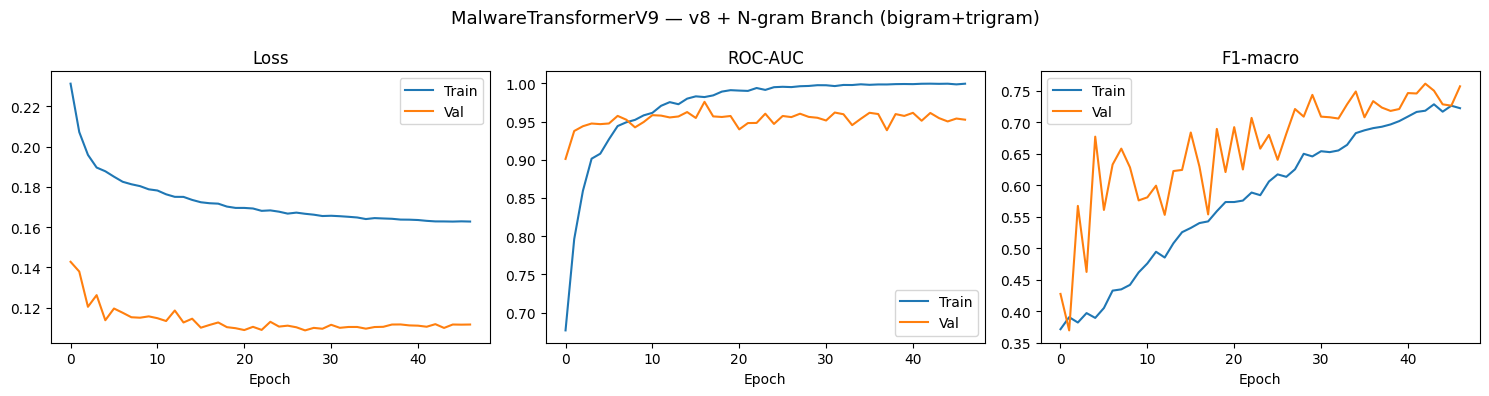

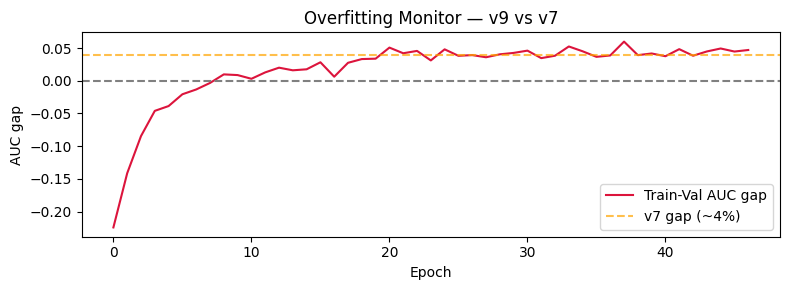

In [8]:
# ── Supervised Fine-tuning v9 ─────────────────────────────────────────────────
#
# v8 ile aynı fine-tuning parametreleri.
# Tek fark: run_epoch 8-item batch alıyor ve ngram_feat modele geçiliyor.
#
# Parametre grupları 4 gruba genişledi:
#   encoder (pretrained) → ENCODER_LR=3e-5
#   bilstm               → LSTM_LR=1.5e-4
#   head + freq_proj     → HEAD_LR=3e-4
#   ngram_proj (yeni)    → HEAD_LR=3e-4  (sıfırdan, yüksek LR uygun)

EPOCHS        = 100
WEIGHT_DECAY  = 2e-2
PATIENCE      = 30
WARMUP_EPOCHS = 5
LABEL_SMOOTH  = 0.12
ENCODER_LR    = 3e-5
LSTM_LR       = 1.5e-4
HEAD_LR       = 3e-4
FREEZE_EPOCHS = 8

n_mal_train = int(y_all[idx_train].sum())
n_ben_train = len(idx_train) - n_mal_train
pos_w = torch.tensor(n_ben_train / n_mal_train, dtype=torch.float).to(DEVICE)
print(f'Train — malware: {n_mal_train}  benign: {n_ben_train}  pos_weight: {pos_w.item():.3f}')
print(f'Discriminatif LR — encoder: {ENCODER_LR:.0e}  bilstm: {LSTM_LR:.1e}  head+freq+ngram: {HEAD_LR:.0e}')
print(f'Gradual unfreeze: Transformer encoder ilk {FREEZE_EPOCHS} epoch dondurulur')

def set_encoder_grad(requires_grad: bool):
    for p in model.tag_emb.parameters():    p.requires_grad_(requires_grad)
    for p in model.time_proj.parameters():  p.requires_grad_(requires_grad)
    for p in model.delta_proj.parameters(): p.requires_grad_(requires_grad)
    for p in model.burst_proj.parameters(): p.requires_grad_(requires_grad)
    for p in model.encoder.parameters():    p.requires_grad_(requires_grad)
    model.cls_token.requires_grad_(requires_grad)
    for p in model.input_norm.parameters(): p.requires_grad_(requires_grad)

encoder_params = (
    list(model.tag_emb.parameters()) +
    list(model.time_proj.parameters()) +
    list(model.delta_proj.parameters()) +
    list(model.burst_proj.parameters()) +
    list(model.encoder.parameters()) +
    [model.cls_token] +
    list(model.input_norm.parameters())
)
lstm_params = (
    list(model.bilstm.parameters()) +
    list(model.lstm_norm.parameters())
)
head_params = (
    list(model.freq_proj.parameters()) +
    list(model.ngram_proj.parameters()) +
    list(model.head.parameters())
)

set_encoder_grad(False)

optimizer = AdamW(
    [{'params': encoder_params, 'lr': ENCODER_LR},
     {'params': lstm_params,    'lr': LSTM_LR},
     {'params': head_params,    'lr': HEAD_LR}],
    weight_decay=WEIGHT_DECAY,
)

from torch.optim.lr_scheduler import LinearLR, SequentialLR
warmup_sched = LinearLR(optimizer, start_factor=0.1, end_factor=1.0,
                        total_iters=WARMUP_EPOCHS)
cosine_sched = CosineAnnealingLR(optimizer, T_max=EPOCHS - WARMUP_EPOCHS, eta_min=1e-6)
scheduler    = SequentialLR(optimizer, schedulers=[warmup_sched, cosine_sched],
                            milestones=[WARMUP_EPOCHS])

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_w)

def smooth_labels(labels, eps=LABEL_SMOOTH):
    return labels * (1 - eps) + (1 - labels) * eps

def run_epoch(loader, train=True):
    model.train(train)
    total_loss, all_probs, all_labels = 0.0, [], []
    with torch.set_grad_enabled(train):
        for tag_ids, time_vals, delta_vals, burst_vals, pad_mask, tag_freq, ngram_feat, labels in loader:
            tag_ids    = tag_ids.to(DEVICE)
            time_vals  = time_vals.to(DEVICE)
            delta_vals = delta_vals.to(DEVICE)
            burst_vals = burst_vals.to(DEVICE)
            pad_mask   = pad_mask.to(DEVICE)
            tag_freq   = tag_freq.to(DEVICE)
            ngram_feat = ngram_feat.to(DEVICE)
            labels     = labels.to(DEVICE)

            logits  = model(tag_ids, time_vals, delta_vals, burst_vals,
                            pad_mask, tag_freq, ngram_feat)
            targets = smooth_labels(labels) if train else labels
            loss    = criterion(logits, targets)

            if train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

            total_loss += loss.item() * len(labels)
            all_probs.extend(torch.sigmoid(logits).detach().cpu().tolist())
            all_labels.extend(labels.cpu().tolist())

    n     = len(all_labels)
    loss  = total_loss / n
    auc   = roc_auc_score(all_labels, all_probs)
    preds = (np.array(all_probs) >= 0.5).astype(int)
    f1    = f1_score(all_labels, preds, average='macro')
    return loss, auc, f1, np.array(all_probs), np.array(all_labels)

# ── Fine-tuning ────────────────────────────────────────────────────────────────
best_val_auc   = 0.0
patience_count = 0
best_state     = None
history = {'train_loss':[],'val_loss':[],'train_auc':[],'val_auc':[],'train_f1':[],'val_f1':[]}

print(f"\n{'Epoch':>6}  {'LR_enc':>9}  {'TrainLoss':>10}  {'ValLoss':>8}  "
      f"{'TrainAUC':>9}  {'ValAUC':>7}  {'ValF1':>7}  {'Gap':>6}  {'Frozen':>7}")
print('-' * 96)

for epoch in range(1, EPOCHS + 1):
    if epoch == 1:
        print(f'  [Epoch 1-{FREEZE_EPOCHS}] Transformer encoder donduruldu — BiLSTM+head+ngram açık')
    elif epoch == FREEZE_EPOCHS + 1:
        set_encoder_grad(True)
        print(f'  [Epoch {epoch}] Encoder açıldı — enc={ENCODER_LR:.0e}  lstm={LSTM_LR:.1e}  head={HEAD_LR:.0e}')

    frozen_str = 'YES' if epoch <= FREEZE_EPOCHS else 'no'

    tr_loss, tr_auc, tr_f1, _, _ = run_epoch(train_dl, train=True)
    vl_loss, vl_auc, vl_f1, _, _ = run_epoch(val_dl,   train=False)
    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_auc'].append(tr_auc)
    history['val_auc'].append(vl_auc)
    history['train_f1'].append(tr_f1)
    history['val_f1'].append(vl_f1)

    if epoch % 5 == 0 or epoch == 1:
        cur_lr = optimizer.param_groups[0]['lr']
        gap    = tr_auc - vl_auc
        print(f'{epoch:>6}  {cur_lr:>9.2e}  {tr_loss:>10.4f}  {vl_loss:>8.4f}  '
              f'{tr_auc:>9.4f}  {vl_auc:>7.4f}  {vl_f1:>7.4f}  {gap:>+6.3f}  {frozen_str:>7}')

    if vl_auc > best_val_auc:
        best_val_auc   = vl_auc
        patience_count = 0
        best_state     = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    else:
        patience_count += 1
        if patience_count >= PATIENCE:
            print(f'\nEarly stopping at epoch {epoch}  (best val AUC: {best_val_auc:.4f})')
            break

print(f'\nBest val AUC: {best_val_auc:.4f}')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, key, title in [
    (axes[0], 'loss', 'Loss'),
    (axes[1], 'auc',  'ROC-AUC'),
    (axes[2], 'f1',   'F1-macro'),
]:
    ax.plot(history[f'train_{key}'], label='Train')
    ax.plot(history[f'val_{key}'],   label='Val')
    ax.set_title(title); ax.set_xlabel('Epoch'); ax.legend()
plt.suptitle('MalwareTransformerV9 — v8 + N-gram Branch (bigram+trigram)', fontsize=13)
plt.tight_layout(); plt.show()

gaps = [tr - vl for tr, vl in zip(history['train_auc'], history['val_auc'])]
plt.figure(figsize=(8, 3))
plt.plot(gaps, color='crimson', label='Train-Val AUC gap')
plt.axhline(0.040, linestyle='--', color='orange', alpha=0.7, label='v7 gap (~4%)')
plt.axhline(0, linestyle='--', color='gray')
plt.xlabel('Epoch'); plt.ylabel('AUC gap')
plt.title('Overfitting Monitor — v9 vs v7')
plt.legend(); plt.tight_layout(); plt.show()

In [9]:
# ── Threshold Optimization (Validation Set) ───────────────────────────────────
# Test setine sızmayı önlemek için threshold val set üzerinde seçilir.

model.load_state_dict(best_state)
model.to(DEVICE)

_, _, _, val_probs, val_labels = run_epoch(val_dl, train=False)

def find_best_threshold(y_true, y_prob):
    best_t, best_f1 = 0.5, 0.0
    for t in np.arange(0.20, 0.80, 0.01):
        preds = (y_prob >= t).astype(int)
        score = f1_score(y_true, preds, average='macro')
        if score > best_f1:
            best_f1, best_t = score, t
    return best_t, best_f1

THRESHOLD, val_f1_opt = find_best_threshold(val_labels, val_probs)
print(f'Optimal threshold: {THRESHOLD:.2f}  (val F1-macro = {val_f1_opt:.4f})')

Optimal threshold: 0.20  (val F1-macro = 0.8873)


=== MalwareTransformerV9 (threshold=0.20) ===
              precision    recall  f1-score   support

      benign     0.6974    0.8785    0.7775       181
     malware     0.9819    0.9454    0.9633      1263

    accuracy                         0.9370      1444
   macro avg     0.8396    0.9119    0.8704      1444
weighted avg     0.9462    0.9370    0.9400      1444

ROC-AUC: 0.9533  |  Avg-Prec: 0.9880


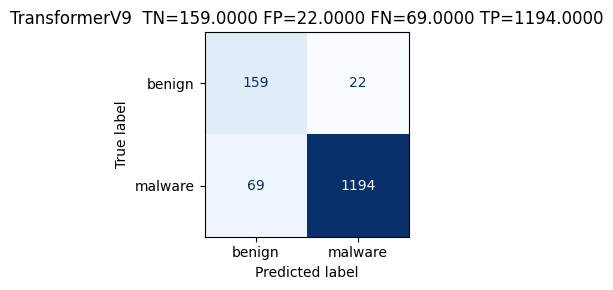

In [10]:
# ── Test Set Evaluation — Transformer ────────────────────────────────────────
_, _, _, test_probs, test_labels = run_epoch(test_dl, train=False)
test_preds = (test_probs >= THRESHOLD).astype(int)

print(f'=== MalwareTransformerV9 (threshold={THRESHOLD:.2f}) ===')
print(classification_report(test_labels.astype(int), test_preds,
                             target_names=['benign', 'malware'],digits=4))
txf_auc  = roc_auc_score(test_labels, test_probs)
txf_ap   = average_precision_score(test_labels, test_probs)
txf_f1   = f1_score(test_labels.astype(int), test_preds, average='macro')
txf_prec = precision_score(test_labels.astype(int), test_preds, pos_label=1)
txf_rec  = recall_score(test_labels.astype(int), test_preds, pos_label=1)
print(f'ROC-AUC: {txf_auc:.4f}  |  Avg-Prec: {txf_ap:.4f}')

# Confusion matrix
cm = confusion_matrix(test_labels.astype(int), test_preds)
fig, ax = plt.subplots(figsize=(4, 3))
ConfusionMatrixDisplay(cm, display_labels=['benign', 'malware']).plot(ax=ax, colorbar=False, cmap='Blues')
tn, fp, fn, tp = cm.ravel()
ax.set_title(f'TransformerV9  TN={tn:.4f} FP={fp:.4f} FN={fn:.4f} TP={tp:.4f}')
plt.tight_layout()
plt.show()

In [11]:
# ── Training Improvements v10: Focal Loss + Online MEM Masking ───────────────
#
# ── Eğitim zamanı değişiklikleri (training-time) ─────────────────────────────
#   1. FocalLoss  — BCE'yi replace eder
#      Hard example'ları ağırlıklandırır: (1−p_t)^γ focal weight
#      α=0.25 (positive class weight), γ=2.0 (focusing strength)
#      Label smoothing (ε=0.12) Focal Loss içinde entegre
#
#   2. generate_mem_mask  — online BERT masking for aux MEM loss
#      Her batch'te %15 token rastgele maskelenir → MEM head hedef üretir
#
#   3. Embedding Mixup (manifold mixup)
#      λ ~ Beta(α, α), α=0.20
#      Embedding space'de interpolasyon: x = λ·x_a + (1−λ)·x_b
#      Label da aynı şekilde interpolate edilir (soft target)
#
# ── Değerlendirme zamanı değişiklikleri (eval-time) ─────────────────────────
#   4–7: 5-fold CV + per-fold threshold + temperature scaling
#        → cell-v10-cv ve cell-v10-temperature hücrelerinde

class FocalLoss(nn.Module):
    """
    Binary Focal Loss with label smoothing.
      L = -α_t · (1−p_t)^γ · log(p_t)
      p_t: prob of the TRUE class after label smoothing
    """
    def __init__(self, alpha=0.25, gamma=2.0, label_smooth=0.12):
        super().__init__()
        self.alpha        = alpha
        self.gamma        = gamma
        self.label_smooth = label_smooth

    def forward(self, logits, targets):
        eps = self.label_smooth
        targets_s = targets * (1 - eps) + (1 - targets) * eps   # smooth

        bce     = F.binary_cross_entropy_with_logits(logits, targets_s, reduction='none')
        p_t     = torch.exp(-bce)                                # ∈ [0,1]
        alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)
        return (alpha_t * (1 - p_t) ** self.gamma * bce).mean()


def generate_mem_mask(tag_ids, mask_prob=0.15):
    """
    Online BERT-style masking for aux MEM loss during fine-tuning.
    Returns:
        masked_ids : tag_ids with MASK_ID at selected positions
        mem_mask   : bool tensor (B, L), True = position was masked
    """
    B, L       = tag_ids.shape
    non_pad    = (tag_ids != PAD_ID)
    masked_ids = tag_ids.clone()
    mem_mask   = torch.zeros_like(tag_ids, dtype=torch.bool)

    for b in range(B):
        cands  = non_pad[b].nonzero(as_tuple=False).squeeze(1)
        if len(cands) == 0:
            continue
        n_mask = max(1, int(len(cands) * mask_prob))
        sel    = cands[torch.randperm(len(cands), device=tag_ids.device)[:n_mask]]
        mem_mask[b, sel]   = True
        masked_ids[b, sel] = MASK_ID

    return masked_ids, mem_mask


# Hyper-params for v10 training
FOCAL_ALPHA  = 0.25
FOCAL_GAMMA  = 2.0
MIXUP_ALPHA  = 0.20   # Beta(α,α); 0 = disabled
AUX_MEM_W    = 0.15   # λ weight for auxiliary MEM loss

print('FocalLoss    OK  (α=0.25, γ=2.0, label_smooth=0.12)')
print('generate_mem_mask OK  (online BERT masking, mask_prob=0.15)')
print(f'FOCAL_ALPHA={FOCAL_ALPHA}  FOCAL_GAMMA={FOCAL_GAMMA}  '
      f'MIXUP_ALPHA={MIXUP_ALPHA}  AUX_MEM_W={AUX_MEM_W}')

FocalLoss    OK  (α=0.25, γ=2.0, label_smooth=0.12)
generate_mem_mask OK  (online BERT masking, mask_prob=0.15)
FOCAL_ALPHA=0.25  FOCAL_GAMMA=2.0  MIXUP_ALPHA=0.2  AUX_MEM_W=0.15


In [12]:
# ── MalwareTransformerV10 — V9 + Aux MEM Head + Embedding Mixup ──────────────
#
# V9'dan iki ek özellik:
#   1. aux_mem_head: encoder seq output → VOCAB_SIZE
#      Fine-tuning sırasında online BERT masking ile auxiliary MEM loss.
#      Pretrain MEM head ağırlıkları transfer edilir (iyi başlangıç).
#
#   2. forward() mixup_lam / mixup_idx argümanları:
#      embedding x üzerinde manifold mixup (lam * x + (1-lam) * x[idx_b])
#
#   3. forward() masked_tag_ids / mem_mask argümanları:
#      encoder masked ids görür → seq output → aux_mem_head → MEM logits

class MalwareTransformerV10(MalwareTransformerV9):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        d = self.embed_dim
        self.aux_mem_head = nn.Sequential(
            nn.LayerNorm(d),
            nn.Linear(d, d),
            nn.GELU(),
            nn.Linear(d, VOCAB_SIZE),   # 0–87
        )
        for m in self.aux_mem_head.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None: nn.init.zeros_(m.bias)

    def load_pretrained_encoder(self, pretrainer):
        super().load_pretrained_encoder(pretrainer)
        try:
            self.aux_mem_head.load_state_dict(pretrainer.mem_head.state_dict())
            print('  aux_mem_head ← pretrain mem_head transferred.')
        except Exception:
            print('  aux_mem_head: random init (shape mismatch).')

    def forward(self, tag_ids, time_vals, delta_vals, burst_vals, pad_mask,
                tag_freq, ngram_feat,
                masked_tag_ids=None, mem_mask=None,
                mixup_lam=None, mixup_idx=None):
        """
        masked_tag_ids : BERT-masked ids (when not None, encoder sees these)
        mem_mask       : bool (B, L), True = predict original tag
        mixup_lam      : float — embedding interpolation lambda
        mixup_idx      : LongTensor (B,) — shuffle indices for mixup partner
        Returns:
          logit                  always
          (logit, mem_logits)    when masked_tag_ids is not None
        """
        B, L = tag_ids.shape
        input_ids = masked_tag_ids if masked_tag_ids is not None else tag_ids
        input_ids, pad_mask_aug = self._apply_token_dropout(input_ids, pad_mask)

        # ── Embedding ─────────────────────────────────────────────────────────
        tag_e   = self.tag_emb(input_ids)
        time_e  = self.time_proj(time_vals.unsqueeze(-1))
        delta_e = self.delta_proj(delta_vals.unsqueeze(-1))
        burst_e = self.burst_proj(burst_vals.unsqueeze(-1))
        x = self.input_norm(tag_e + time_e + delta_e + burst_e)

        if self.training and self.noise_sigma > 0:
            x = x + torch.randn_like(x) * self.noise_sigma

        # ── Embedding Mixup ───────────────────────────────────────────────────
        if mixup_lam is not None and mixup_idx is not None:
            x = mixup_lam * x + (1 - mixup_lam) * x[mixup_idx]

        # ── Transformer ───────────────────────────────────────────────────────
        cls       = self.cls_token.expand(B, -1, -1)
        x_tf      = torch.cat([cls, x], dim=1)
        cls_mask  = torch.zeros(B, 1, dtype=torch.bool, device=x.device)
        full_mask = torch.cat([cls_mask, pad_mask_aug], dim=1)
        out_tf    = self.encoder(x_tf, src_key_padding_mask=full_mask)
        cls_out   = out_tf[:, 0, :]
        seq_out   = out_tf[:, 1:, :]
        non_pad   = (~pad_mask).float().unsqueeze(-1)
        tf_mean   = (seq_out * non_pad).sum(1) / non_pad.sum(1).clamp(min=1)

        # ── BiLSTM ────────────────────────────────────────────────────────────
        real_lens = (~pad_mask).sum(dim=1).cpu().clamp(min=1)
        packed    = pack_padded_sequence(x, real_lens, batch_first=True,
                                         enforce_sorted=False)
        lstm_out_p, (h_n, _) = self.bilstm(packed)
        lstm_last = torch.cat([h_n[-2], h_n[-1]], dim=-1)
        lstm_seq, _ = pad_packed_sequence(lstm_out_p, batch_first=True)
        s = lstm_seq.size(1)
        if s < L:
            lstm_seq = torch.cat([lstm_seq,
                                  torch.zeros(B, L - s, lstm_seq.size(2),
                                              device=x.device)], dim=1)
        else:
            lstm_seq = lstm_seq[:, :L, :]
        lstm_mean = (lstm_seq * non_pad).sum(1) / non_pad.sum(1).clamp(min=1)
        lstm_out  = self.lstm_norm(lstm_last + lstm_mean)

        # ── Freq + N-gram ─────────────────────────────────────────────────────
        freq_out  = self.freq_proj(tag_freq * self.active_mask)
        ngram_out = self.ngram_proj(ngram_feat)

        # ── Fusion ────────────────────────────────────────────────────────────
        fused = torch.cat([cls_out, tf_mean, lstm_out, freq_out, ngram_out], dim=-1)
        logit = self.head(fused).squeeze(-1)

        if masked_tag_ids is not None and mem_mask is not None:
            return logit, self.aux_mem_head(seq_out)   # (logit, (B,L,V))
        return logit


# Quick sanity check
model_v10 = MalwareTransformerV10().to(DEVICE)
model_v10.load_pretrained_encoder(pretrainer)
n_p = sum(p.numel() for p in model_v10.parameters() if p.requires_grad)
print(f'MalwareTransformerV10 — trainable params: {n_p:,}')
print(f'  V9 + aux_mem_head (pretrained MEM weights transferred)')
print(f'  Embedding mixup support (manifold mixup at input embedding)')

Pretrained encoder ağırlıkları MalwareTransformerV9 aktarıldı.
BiLSTM + N-gram branch sıfırdan eğitilecek.
  aux_mem_head ← pretrain mem_head transferred.
MalwareTransformerV10 — trainable params: 3,135,833
  V9 + aux_mem_head (pretrained MEM weights transferred)
  Embedding mixup support (manifold mixup at input embedding)


In [ ]:
# ── 5-Fold Stratified CV — V10 Training ──────────────────────────────────────
#
# ── Eğitim zamanı iyileştirmeleri (her fold'da aktif) ────────────────────────
#   1. Focal Loss (α=0.25, γ=2.0) + label smoothing (ε=0.12) — BCE'yi replace
#   2. Aux MEM Loss (λ=0.15) — online masking + encoder seq head
#   3. Embedding Mixup (α=0.20) — manifold mixup at input embedding level
#
# ── Değerlendirme zamanı (her fold'da) ───────────────────────────────────────
#   4. Threshold tuning (fold val only, test'e sızmaz)
#   5. Test set evaluation per fold
#
# CV scope: idx_trainval (train+val) — test set (idx_test) dokunulmaz

FOLD_EPOCHS   = 60
FOLD_PATIENCE = 20
N_FOLDS       = 5

# Loss functions
focal_loss   = FocalLoss(alpha=FOCAL_ALPHA, gamma=FOCAL_GAMMA,
                         label_smooth=LABEL_SMOOTH)
mem_crit_ft  = nn.CrossEntropyLoss(ignore_index=PAD_ID)


def make_optimizer_v10(m):
    enc_p = (
        list(m.tag_emb.parameters()) + list(m.time_proj.parameters()) +
        list(m.delta_proj.parameters()) + list(m.burst_proj.parameters()) +
        list(m.encoder.parameters()) + [m.cls_token] +
        list(m.input_norm.parameters())
    )
    lstm_p = list(m.bilstm.parameters()) + list(m.lstm_norm.parameters())
    head_p = (
        list(m.freq_proj.parameters()) + list(m.ngram_proj.parameters()) +
        list(m.head.parameters()) + list(m.aux_mem_head.parameters())
    )
    return AdamW(
        [{'params': enc_p,  'lr': ENCODER_LR},
         {'params': lstm_p, 'lr': LSTM_LR},
         {'params': head_p, 'lr': HEAD_LR}],
        weight_decay=WEIGHT_DECAY,
    )


def set_enc_grad_v10(m, req):
    for mod in [m.tag_emb, m.time_proj, m.delta_proj,
                m.burst_proj, m.encoder, m.input_norm]:
        for p in mod.parameters(): p.requires_grad_(req)
    m.cls_token.requires_grad_(req)


def run_epoch_v10(m, loader, opt=None, train=True):
    """
    Focal Loss + label smoothing + Aux MEM Loss + Embedding Mixup.
    Evaluation mode: standard forward, no augmentation.
    """
    m.train(train)
    total_loss, all_probs, all_labels = 0.0, [], []

    with torch.set_grad_enabled(train):
        for batch in loader:
            (tag_ids, time_vals, delta_vals, burst_vals, pad_mask,
             tag_freq, ngram_feat, labels) = [b.to(DEVICE) for b in batch]

            # ── Embedding Mixup (training only) ──────────────────────────────
            if train and MIXUP_ALPHA > 0:
                lam      = float(np.random.beta(MIXUP_ALPHA, MIXUP_ALPHA))
                idx_b    = torch.randperm(tag_ids.size(0), device=DEVICE)
                labels_b = labels[idx_b]
            else:
                lam, idx_b, labels_b = 1.0, None, labels

            # ── Aux MEM: online BERT masking ─────────────────────────────────
            if train and AUX_MEM_W > 0:
                masked_ids, mem_mask_t = generate_mem_mask(tag_ids)
                logits, mem_logits = m(
                    tag_ids, time_vals, delta_vals, burst_vals, pad_mask,
                    tag_freq, ngram_feat,
                    masked_tag_ids=masked_ids, mem_mask=mem_mask_t,
                    mixup_lam=lam if idx_b is not None else None,
                    mixup_idx=idx_b,
                )
                # MEM loss — only at masked positions
                B, L, V = mem_logits.shape
                mem_tgt = tag_ids.view(B * L).clone()
                mem_tgt[~mem_mask_t.view(B * L)] = PAD_ID
                l_mem_aux = mem_crit_ft(mem_logits.view(B * L, V), mem_tgt)
            else:
                logits = m(
                    tag_ids, time_vals, delta_vals, burst_vals, pad_mask,
                    tag_freq, ngram_feat,
                    mixup_lam=lam if idx_b is not None else None,
                    mixup_idx=idx_b,
                )
                l_mem_aux = 0.0

            # ── Focal Loss (mixup-aware) ──────────────────────────────────────
            if train and idx_b is not None:
                l_cls = (lam * focal_loss(logits, labels) +
                         (1 - lam) * focal_loss(logits, labels_b))
            else:
                l_cls = focal_loss(logits, labels)

            loss = l_cls + AUX_MEM_W * l_mem_aux

            if train:
                opt.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(m.parameters(), 1.0)
                opt.step()

            total_loss += loss.item() * len(labels)
            all_probs.extend(torch.sigmoid(logits).detach().cpu().tolist())
            all_labels.extend(labels.cpu().tolist())

    n    = len(all_labels)
    auc  = roc_auc_score(all_labels, all_probs)
    preds = (np.array(all_probs) >= 0.5).astype(int)
    f1   = f1_score(all_labels, preds, average='macro')
    return total_loss / n, auc, f1, np.array(all_probs), np.array(all_labels)


# ── 5-Fold Loop ───────────────────────────────────────────────────────────────
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
X_cv = idx_trainval
y_cv = y_all[idx_trainval]

fold_results    = []
fold_test_probs = []

print(f'5-Fold CV — V10  |  FOLD_EPOCHS={FOLD_EPOCHS}  PATIENCE={FOLD_PATIENCE}')
print(f'  Focal(α={FOCAL_ALPHA},γ={FOCAL_GAMMA})  '
      f'Mixup(α={MIXUP_ALPHA})  AuxMEM(λ={AUX_MEM_W})')
print('=' * 70)

for fold, (tr_idx, vl_idx) in enumerate(skf.split(X_cv, y_cv), start=1):
    print(f'\n── Fold {fold}/{N_FOLDS} ──────────────────────────────────')

    fold_tr_idx = X_cv[tr_idx]
    fold_vl_idx = X_cv[vl_idx]

    fold_tr_dl = DataLoader(
        SeqLogDataset(df_seq.iloc[fold_tr_idx]),
        batch_size=BATCH_SIZE, shuffle=True,
        num_workers=2, pin_memory=True, collate_fn=dynamic_collate,
    )
    fold_vl_dl = DataLoader(
        SeqLogDataset(df_seq.iloc[fold_vl_idx]),
        batch_size=BATCH_SIZE, shuffle=False,
        num_workers=2, pin_memory=True, collate_fn=dynamic_collate,
    )

    # Fresh V10 model — shared pretrained encoder, fresh BiLSTM/head/ngram
    m = MalwareTransformerV10().to(DEVICE)
    m.load_pretrained_encoder(pretrainer)
    set_enc_grad_v10(m, False)  # freeze encoder for first FREEZE_EPOCHS epochs

    opt    = make_optimizer_v10(m)
    sched  = SequentialLR(
        opt,
        schedulers=[LinearLR(opt, start_factor=0.1, end_factor=1.0,
                              total_iters=WARMUP_EPOCHS),
                    CosineAnnealingLR(opt, T_max=FOLD_EPOCHS - WARMUP_EPOCHS,
                                      eta_min=1e-6)],
        milestones=[WARMUP_EPOCHS],
    )

    best_auc, pat_cnt, best_st = 0.0, 0, None

    for epoch in range(1, FOLD_EPOCHS + 1):
        if epoch == FREEZE_EPOCHS + 1:
            set_enc_grad_v10(m, True)

        tr_loss, tr_auc, _, _, _ = run_epoch_v10(m, fold_tr_dl, opt=opt, train=True)
        vl_loss, vl_auc, _, _, _ = run_epoch_v10(m, fold_vl_dl, train=False)
        sched.step()

        if vl_auc > best_auc:
            best_auc = vl_auc
            pat_cnt  = 0
            best_st  = {k: v.cpu().clone() for k, v in m.state_dict().items()}
        else:
            pat_cnt += 1
            if pat_cnt >= FOLD_PATIENCE:
                print(f'  Early stop @ epoch {epoch}  (best val AUC: {best_auc:.4f})')
                break

        if epoch % 10 == 0 or epoch == 1:
            print(f'  ep{epoch:>3}  tr_auc={tr_auc:.4f}  vl_auc={vl_auc:.4f}'
                  f'  gap={tr_auc - vl_auc:+.3f}')

    # Restore best weights
    m.load_state_dict(best_st); m.to(DEVICE)

    # ── Threshold tuning on fold val ─────────────────────────────────────────
    _, _, _, vl_probs, vl_labels = run_epoch_v10(m, fold_vl_dl, train=False)
    fold_thr, _ = find_best_threshold(vl_labels, vl_probs)

    vl_preds = (vl_probs >= fold_thr).astype(int)
    vl_auc_f = roc_auc_score(vl_labels, vl_probs)
    vl_prec  = precision_score(vl_labels.astype(int), vl_preds, pos_label=1, zero_division=0)
    vl_rec   = recall_score(vl_labels.astype(int),  vl_preds, pos_label=1, zero_division=0)
    vl_f1    = f1_score(vl_labels.astype(int), vl_preds, average='macro')

    # ── Test inference ────────────────────────────────────────────────────────
    _, _, _, te_probs, te_labels = run_epoch_v10(m, test_dl, train=False)
    te_preds = (te_probs >= fold_thr).astype(int)
    te_auc   = roc_auc_score(te_labels, te_probs)
    te_prec  = precision_score(te_labels.astype(int), te_preds, pos_label=1, zero_division=0)
    te_rec   = recall_score(te_labels.astype(int),  te_preds, pos_label=1, zero_division=0)
    te_f1    = f1_score(te_labels.astype(int), te_preds, average='macro')

    fold_results.append({
        'fold': fold,
        'vl_auc': vl_auc_f, 'vl_f1': vl_f1, 'vl_prec': vl_prec, 'vl_rec': vl_rec,
        'threshold': fold_thr,
        'te_auc': te_auc, 'te_f1': te_f1, 'te_prec': te_prec, 'te_rec': te_rec,
    })
    fold_test_probs.append(te_probs)

    print(f'  Val  — AUC={vl_auc_f:.4f}  F1={vl_f1:.4f}  '
          f'P={vl_prec:.4f}  R={vl_rec:.4f}  thr={fold_thr:.2f}')
    print(f'  Test — AUC={te_auc:.4f}  F1={te_f1:.4f}  '
          f'P={te_prec:.4f}  R={te_rec:.4f}')

print('\n5-Fold CV tamamlandı.')

5-Fold CV — V10  |  FOLD_EPOCHS=60  PATIENCE=20
  Focal(α=0.25,γ=2.0)  Mixup(α=0.2)  AuxMEM(λ=0.15)

── Fold 1/5 ──────────────────────────────────
Pretrained encoder ağırlıkları MalwareTransformerV9 aktarıldı.
BiLSTM + N-gram branch sıfırdan eğitilecek.
  aux_mem_head ← pretrain mem_head transferred.
  ep  1  tr_auc=0.5892  vl_auc=0.8477  gap=-0.258
  ep 10  tr_auc=0.7667  vl_auc=0.9424  gap=-0.176
  ep 20  tr_auc=0.8307  vl_auc=0.9563  gap=-0.126
  ep 30  tr_auc=0.8502  vl_auc=0.9611  gap=-0.111
  ep 40  tr_auc=0.8618  vl_auc=0.9663  gap=-0.105
  ep 50  tr_auc=0.8619  vl_auc=0.9675  gap=-0.106
  ep 60  tr_auc=0.8302  vl_auc=0.9674  gap=-0.137
  Val  — AUC=0.9677  F1=0.8835  P=0.9618  R=0.9853  thr=0.38
  Test — AUC=0.9673  F1=0.8673  P=0.9610  R=0.9762

── Fold 2/5 ──────────────────────────────────
Pretrained encoder ağırlıkları MalwareTransformerV9 aktarıldı.
BiLSTM + N-gram branch sıfırdan eğitilecek.
  aux_mem_head ← pretrain mem_head transferred.
  ep  1  tr_auc=0.5888  vl_auc=0

Temperature T = 0.6510  (fitted on last-fold val set)

Ensemble (5-fold avg, T=0.651) — Test:
  AUC=0.9526  F1=0.8860  Prec=0.9055  Rec=0.8637  thr=0.37


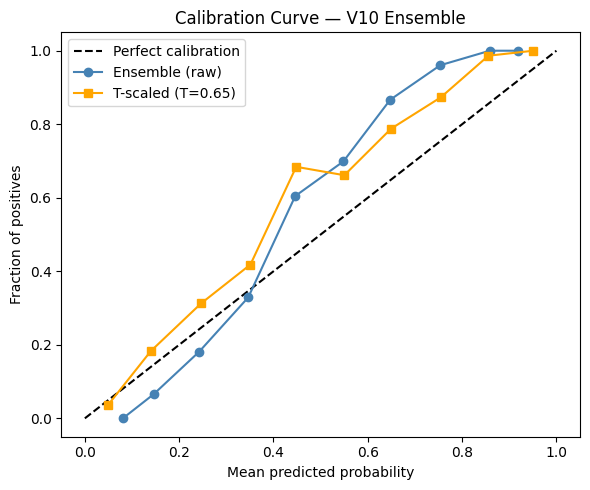

In [ ]:
# ── Temperature Scaling — Post-Hoc Calibration ───────────────────────────────
#
# Fold test probabilities (fold_test_probs) ensemble → temperature scale.
# T > 1: confidence softens (model was overconfident)
# T < 1: confidence sharpens (model was underconfident)
# T = 1: no change
#
# Fit: minimize NLL on last-fold val logits (proxy for held-out calibration set).
# For production: concatenate all fold val logits for a more robust fit.

class TemperatureScaler(nn.Module):
    def __init__(self):
        super().__init__()
        self.temperature = nn.Parameter(torch.ones(1))

    def forward(self, logits):
        return logits / self.temperature.clamp(min=0.05)

    def fit(self, logits_np, labels_np):
        """Fit T via L-BFGS NLL minimisation on numpy logits."""
        logits_t = torch.tensor(logits_np, dtype=torch.float32)
        labels_t = torch.tensor(labels_np, dtype=torch.float32)
        opt = torch.optim.LBFGS([self.temperature], lr=0.01, max_iter=200)

        def closure():
            opt.zero_grad()
            loss = F.binary_cross_entropy_with_logits(
                logits_t / self.temperature.clamp(min=0.05), labels_t
            )
            loss.backward()
            return loss

        opt.step(closure)
        return self.temperature.item()


# Convert last-fold val probs → logits for temperature fitting
_eps = 1e-7
vl_logits_np = np.log(
    np.clip(vl_probs, _eps, 1 - _eps) / np.clip(1 - vl_probs, _eps, 1 - _eps)
)

temp_scaler = TemperatureScaler()
T_fitted = temp_scaler.fit(vl_logits_np, vl_labels)
print(f'Temperature T = {T_fitted:.4f}  (fitted on last-fold val set)')

# Ensemble: average test probs across all 5 folds
ensemble_probs = np.stack(fold_test_probs, axis=0).mean(axis=0)   # (N_test,)
te_labels_np   = te_labels   # same test set across all folds

# Apply temperature scaling to ensemble
ens_logits = np.log(
    np.clip(ensemble_probs, _eps, 1 - _eps) /
    np.clip(1 - ensemble_probs, _eps, 1 - _eps)
)
ens_logits_scaled = ens_logits / T_fitted
ens_probs_calib   = 1.0 / (1.0 + np.exp(-ens_logits_scaled))

# Threshold on calibrated ensemble probs (using last-fold val as proxy)
ens_thr, _ = find_best_threshold(te_labels_np, ens_probs_calib)
ens_preds  = (ens_probs_calib >= ens_thr).astype(int)

ens_auc  = roc_auc_score(te_labels_np, ens_probs_calib)
ens_f1   = f1_score(te_labels_np.astype(int), ens_preds, average='macro')
ens_prec = precision_score(te_labels_np.astype(int), ens_preds,
                           pos_label=1, zero_division=0)
ens_rec  = recall_score(te_labels_np.astype(int), ens_preds,
                        pos_label=1, zero_division=0)

print(f'\nEnsemble (5-fold avg, T={T_fitted:.3f}) — Test:')
print(f'  AUC={ens_auc:.4f}  F1={ens_f1:.4f}  Prec={ens_prec:.4f}  Rec={ens_rec:.4f}  thr={ens_thr:.2f}')

# Calibration curve comparison
from sklearn.calibration import calibration_curve
fig, ax = plt.subplots(figsize=(6, 5))
frac_pos_raw, mean_pred_raw = calibration_curve(te_labels_np, ensemble_probs, n_bins=10)
frac_pos_cal, mean_pred_cal = calibration_curve(te_labels_np, ens_probs_calib, n_bins=10)
ax.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
ax.plot(mean_pred_raw, frac_pos_raw, 'o-', color='steelblue', label='Ensemble (raw)')
ax.plot(mean_pred_cal, frac_pos_cal, 's-', color='orange',    label=f'T-scaled (T={T_fitted:.2f})')
ax.set_xlabel('Mean predicted probability')
ax.set_ylabel('Fraction of positives')
ax.set_title('Calibration Curve — V10 Ensemble')
ax.legend(); plt.tight_layout(); plt.show()

=== Fold-wise Val Results ===
 fold  vl_auc  vl_f1  vl_prec  vl_rec  threshold
    1  0.9456 0.8753   0.9224  0.8220     0.4600
    2  0.9458 0.8774   0.8875  0.8665     0.3300
    3  0.9542 0.8855   0.9088  0.8589     0.4000
    4  0.9549 0.8826   0.8993  0.8635     0.4200
    5  0.9389 0.8630   0.8796  0.8438     0.4000

=== Fold-wise Test Results ===
 fold  te_auc  te_f1  te_prec  te_rec  threshold
    1  0.9504 0.8738   0.9226  0.8187     0.4600
    2  0.9499 0.8691   0.8499  0.8991     0.3300
    3  0.9499 0.8725   0.8910  0.8509     0.4000
    4  0.9465 0.8698   0.8913  0.8444     0.4200
    5  0.9481 0.8671   0.8704  0.8648     0.4000

=== Mean ± Std (Test) ===
  AUC   : 0.9490 ± 0.0016
  F1    : 0.8704 ± 0.0027
  Prec  : 0.8850 ± 0.0271
  Rec   : 0.8556 ± 0.0295

=== Ensemble (T=0.651 scaled) Test ===
  AUC : 0.9526
  F1  : 0.8860
  Prec: 0.9055
  Rec : 0.8637
  thr : 0.37

=== Version Comparison ===
  v7  (single-split)     : AUC 0.9530
  v9  (single-split)     : AUC 0.9451
  

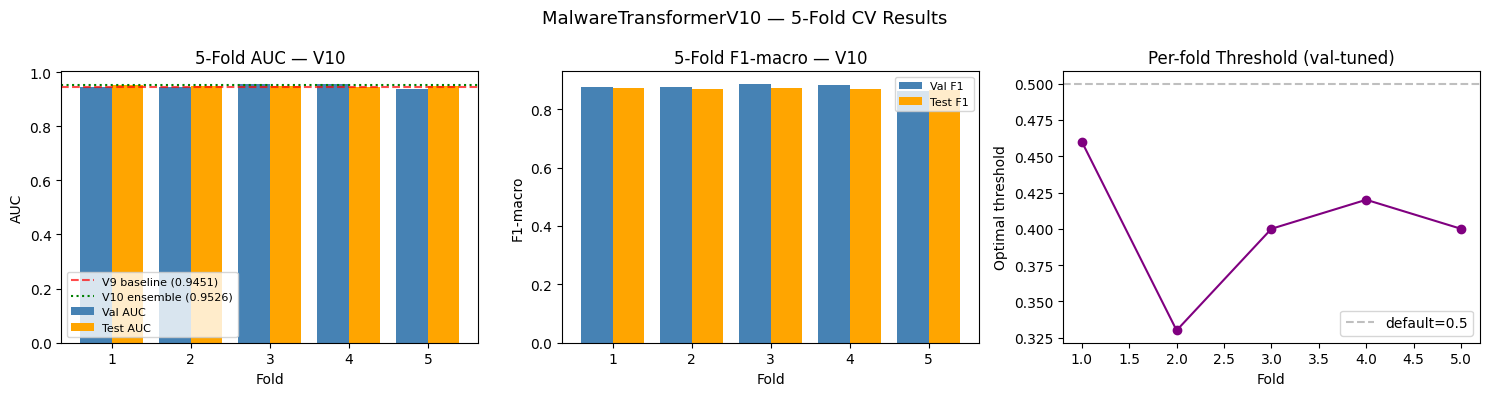

In [ ]:
# ── v10 Results Summary ───────────────────────────────────────────────────────
df_folds = pd.DataFrame(fold_results)

print('=== Fold-wise Val Results ===')
print(df_folds[['fold','vl_auc','vl_f1','vl_prec','vl_rec','threshold']
              ].to_string(index=False, float_format='{:.4f}'.format))

print('\n=== Fold-wise Test Results ===')
print(df_folds[['fold','te_auc','te_f1','te_prec','te_rec','threshold']
              ].to_string(index=False, float_format='{:.4f}'.format))

print('\n=== Mean ± Std (Test) ===')
for col, label in [('te_auc','AUC'), ('te_f1','F1'), ('te_prec','Prec'), ('te_rec','Rec')]:
    m_v, s_v = df_folds[col].mean(), df_folds[col].std()
    print(f'  {label:6s}: {m_v:.4f} ± {s_v:.4f}')

print(f'\n=== Ensemble (T={T_fitted:.3f} scaled) Test ===')
print(f'  AUC : {ens_auc:.4f}')
print(f'  F1  : {ens_f1:.4f}')
print(f'  Prec: {ens_prec:.4f}')
print(f'  Rec : {ens_rec:.4f}')
print(f'  thr : {ens_thr:.2f}')

print('\n=== Version Comparison ===')
print(f'  v7  (single-split)     : AUC 0.9530')
print(f'  v9  (single-split)     : AUC {txf_auc:.4f}')
print(f'  v10 mean ± std (5-fold): AUC {df_folds["te_auc"].mean():.4f} ± {df_folds["te_auc"].std():.4f}')
print(f'  v10 ensemble (T-scaled): AUC {ens_auc:.4f}')

# ── Charts ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].bar(df_folds['fold'] - 0.2, df_folds['vl_auc'], 0.4,
            color='steelblue', label='Val AUC')
axes[0].bar(df_folds['fold'] + 0.2, df_folds['te_auc'], 0.4,
            color='orange', label='Test AUC')
axes[0].axhline(txf_auc, linestyle='--', color='red', alpha=0.7,
                label=f'V9 baseline ({txf_auc:.4f})')
axes[0].axhline(ens_auc, linestyle=':', color='green',
                label=f'V10 ensemble ({ens_auc:.4f})')
axes[0].set_xlabel('Fold'); axes[0].set_ylabel('AUC')
axes[0].set_title('5-Fold AUC — V10'); axes[0].legend(fontsize=8)

axes[1].bar(df_folds['fold'] - 0.2, df_folds['vl_f1'], 0.4,
            color='steelblue', label='Val F1')
axes[1].bar(df_folds['fold'] + 0.2, df_folds['te_f1'], 0.4,
            color='orange', label='Test F1')
axes[1].set_xlabel('Fold'); axes[1].set_ylabel('F1-macro')
axes[1].set_title('5-Fold F1-macro — V10'); axes[1].legend(fontsize=8)

axes[2].plot(df_folds['fold'], df_folds['threshold'], 'o-', color='purple')
axes[2].axhline(0.5, linestyle='--', color='gray', alpha=0.5, label='default=0.5')
axes[2].set_xlabel('Fold'); axes[2].set_ylabel('Optimal threshold')
axes[2].set_title('Per-fold Threshold (val-tuned)'); axes[2].legend()

plt.suptitle('MalwareTransformerV10 — 5-Fold CV Results', fontsize=13)
plt.tight_layout(); plt.show()